Name: Arav Mahind

Roll no: 24102A2008

Branch: CMPN-A

Subject: R Programming

Experiment no: 07

In [32]:
# Install openpyxl if needed for Excel file reading
!pip install -q openpyxl plotly

import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import scipy.cluster.hierarchy as sch
import plotly.express as px

print("All packages imported successfully!")

All packages imported successfully!


In [33]:
# Download Online Retail Dataset from UCI Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
file_name = "Online_Retail.xlsx"

if not os.path.exists(file_name):
    print("Downloading dataset...")
    response = requests.get(url)
    with open(file_name, "wb") as f:
        f.write(response.content)
    print("Download complete.")

df = pd.read_excel(file_name)

# Data Cleaning: Remove missing CustomerIDs, cancelled orders ('C'), and non-positive quantities/prices
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Feature Engineering at Customer Level (RFM + Extended Transaction Metrics)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSpend', 'sum'),
    AvgTxnValue=('TotalSpend', 'mean'),
    TotalQuantity=('Quantity', 'sum'),
    AvgQuantity=('Quantity', 'mean')
).reset_index()

# Outlier Treatment & Feature Scaling (Log Transformation + Standardization)
rfm_features = ['Recency', 'Frequency', 'Monetary', 'AvgTxnValue', 'TotalQuantity', 'AvgQuantity']
rfm_log = np.log1p(customer_rfm[rfm_features])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print(f"Dataset successfully preprocessed. Total Unique Customers: {customer_rfm.shape[0]}")
customer_rfm.head()

Dataset successfully preprocessed. Total Unique Customers: 4338


,CustomerID,Recency,Frequency,Monetary,AvgTxnValue,TotalQuantity,AvgQuantity
0,12346,326,1,77183.60,77183.600000,74215,74215.000000
1,12347,2,7,4310.00,23.681319,2458,13.505495
2,12348,75,4,1797.24,57.975484,2341,75.516129
3,12349,19,1,1757.55,24.076027,631,8.643836
4,12350,310,1,334.40,19.670588,197,11.588235


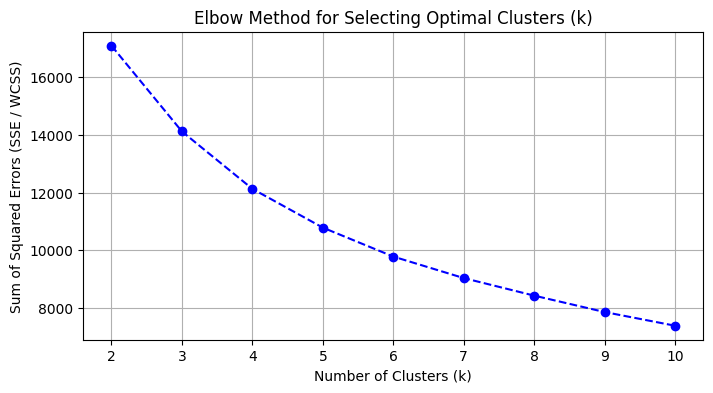

In [34]:
# Determine optimal number of clusters using Within-Cluster Sum of Squares (WCSS)
sse = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Selecting Optimal Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE / WCSS)')
plt.grid(True)
plt.show()

In [35]:
# Apply K-Means with k = 4
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_rfm['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

# Calculate Silhouette Score
sil_score = silhouette_score(rfm_scaled, customer_rfm['Cluster'])
print(f"K-Means Clustering Completed.")
print(f"Overall Silhouette Score for k={optimal_k}: {sil_score:.4f}")

# Cluster Distribution
print("\nCustomer Count per Cluster:")
print(customer_rfm['Cluster'].value_counts().sort_index())

K-Means Clustering Completed.
Overall Silhouette Score for k=4: 0.2337

Customer Count per Cluster:
Cluster
0    1595
1     335
2     796
3    1612
Name: count, dtype: int64


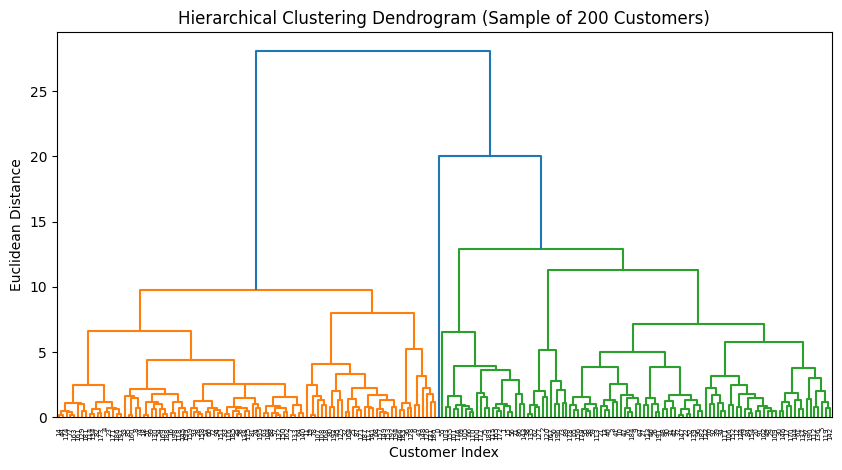

In [36]:
# Sample 200 customer records for clear visual rendering of the dendrogram
sample_scaled = rfm_scaled[:200]

plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(sample_scaled, method='ward'))
plt.title('Hierarchical Clustering Dendrogram (Sample of 200 Customers)')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()

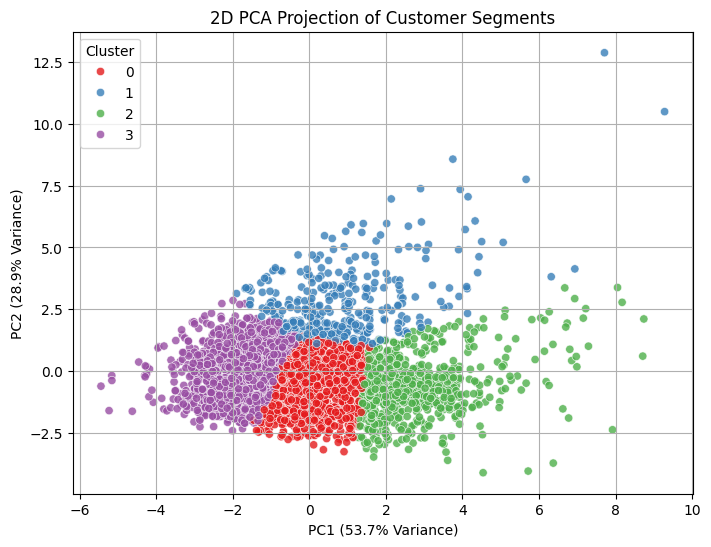

In [37]:
# Principal Component Analysis for 2D visual projection
pca_2d = PCA(n_components=2)
pca_2d_coords = pca_2d.fit_transform(rfm_scaled)

customer_rfm['PC1'] = pca_2d_coords[:, 0]
customer_rfm['PC2'] = pca_2d_coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set1', data=customer_rfm, alpha=0.8)
plt.title('2D PCA Projection of Customer Segments')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True)
plt.show()

In [38]:
# Mean purchasing characteristics across identified clusters
cluster_profile = customer_rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Frequency_Orders=('Frequency', 'mean'),
    Avg_Monetary_Spend=('Monetary', 'mean'),
    Avg_Transaction_Value=('AvgTxnValue', 'mean'),
    Avg_Total_Quantity=('TotalQuantity', 'mean')
).reset_index()

print("--- CLUSTER PROFILING SUMMARY ---")
display(cluster_profile)

# Dynamically extract High-Value cluster based on highest average monetary spend
high_val_cluster = cluster_profile.loc[cluster_profile['Avg_Monetary_Spend'].idxmax(), 'Cluster']
print(f"\nTarget High-Value Customer Segment: Cluster {high_val_cluster}")

--- CLUSTER PROFILING SUMMARY ---


,Cluster,Customer_Count,Avg_Recency_Days,Avg_Frequency_Orders,Avg_Monetary_Spend,Avg_Transaction_Value,Avg_Total_Quantity
0,0,1595,52.452038,3.351097,1085.345469,16.695623,638.097806
1,1,335,122.982090,2.504478,2645.685582,634.219624,1709.952239
2,2,796,18.639447,12.866834,7329.824372,33.061311,4179.054020
3,3,1612,162.361042,1.306452,285.010553,19.289452,155.511787



Target High-Value Customer Segment: Cluster 2


In [39]:
# Binary target label creation: High-Value Cluster (1) vs Other Clusters (0)
X = rfm_log
y = (customer_rfm['Cluster'] == high_val_cluster).astype(int)

# 80/20 Train-Test Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# 2. Support Vector Machine Classifier
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_probs = svm.predict_proba(X_test)[:, 1]

print("Model training complete!")

Model training complete!


--- SUPERVISED MODEL PERFORMANCE METRICS ---


,Metric,Random Forest,SVM
0,Accuracy,0.986175,0.987327
1,Precision,0.986755,0.968354
2,Recall,0.937107,0.962264
3,F1-Score,0.961290,0.965300
4,ROC-AUC,0.999259,0.999219


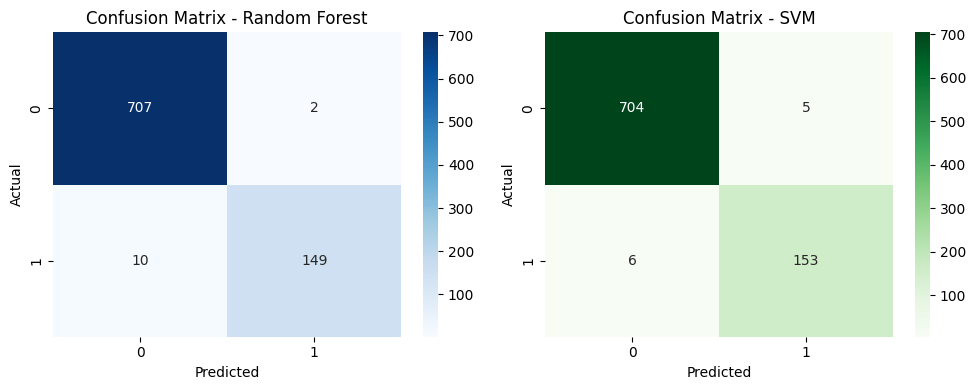

In [40]:
# Compute Classification Metrics
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds),
        roc_auc_score(y_test, rf_probs)
    ],
    'SVM': [
        accuracy_score(y_test, svm_preds),
        precision_score(y_test, svm_preds),
        recall_score(y_test, svm_preds),
        f1_score(y_test, svm_preds),
        roc_auc_score(y_test, svm_probs)
    ]
}

performance_df = pd.DataFrame(metrics_data)

print("--- SUPERVISED MODEL PERFORMANCE METRICS ---")
display(performance_df)

# Confusion Matrices Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - SVM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

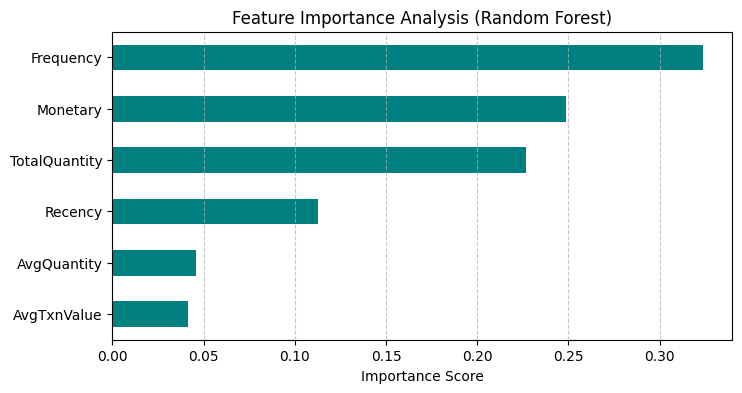

In [41]:
# Feature Importance plot extracted from Random Forest model
plt.figure(figsize=(8, 4))
feat_importances = pd.Series(rf.feature_importances_, index=rfm_features)
feat_importances.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Feature Importance Analysis (Random Forest)')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [42]:
# 3-Component PCA projection for interactive rendering
pca_3d = PCA(n_components=3)
pca_3d_coords = pca_3d.fit_transform(rfm_scaled)

customer_rfm['PC1_3D'] = pca_3d_coords[:, 0]
customer_rfm['PC2_3D'] = pca_3d_coords[:, 1]
customer_rfm['PC3_3D'] = pca_3d_coords[:, 2]

fig_3d = px.scatter_3d(
    customer_rfm,
    x='PC1_3D', y='PC2_3D', z='PC3_3D',
    color=customer_rfm['Cluster'].astype(str),
    title='Interactive 3D Customer Clusters Projection',
    labels={'color': 'Cluster'},
    opacity=0.7,
    size_max=4
)

fig_3d.show()

In [43]:
print("""
================================================================================
ACTIONABLE MARKETING STRATEGIES BY CUSTOMER GROUP
================================================================================

1. VIP / High-Value Champions
   Treat these customers like royalty. Since they generate most of the revenue,
   the priority is keeping them happy through exclusive previews, priority customer
   support, and personalized luxury rewards.

2. At-Risk Customers
   These customers used to buy regularly but haven't visited lately. Re-engage
   them using win-back discounts and quick surveys to fix any dissatisfaction
   before they churn completely.

3. Steady / Potential VIPs
   These buyers visit frequently but spend moderate amounts. Boost their order value
   by recommending matching products, offering bundle deals, and loyalty incentives.

4. Casual / One-Time Buyers
   They buy occasionally and spend small amounts. Keep marketing costs low by
   including them in automated email campaigns, festive sales, and clear product
   recommendations.
================================================================================
""")


ACTIONABLE MARKETING STRATEGIES BY CUSTOMER GROUP

1. VIP / High-Value Champions
   Treat these customers like royalty. Since they generate most of the revenue, 
   the priority is keeping them happy through exclusive previews, priority customer 
   support, and personalized luxury rewards.

2. At-Risk Customers
   These customers used to buy regularly but haven't visited lately. Re-engage 
   them using win-back discounts and quick surveys to fix any dissatisfaction 
   before they churn completely.

3. Steady / Potential VIPs
   These buyers visit frequently but spend moderate amounts. Boost their order value 
   by recommending matching products, offering bundle deals, and loyalty incentives.

4. Casual / One-Time Buyers
   They buy occasionally and spend small amounts. Keep marketing costs low by 
   including them in automated email campaigns, festive sales, and clear product 
   recommendations.



Conclusion

Successfully transformed transactional retail data into customer-level RFM features and segmented buyers into 4 distinct groups using K-Means and Hierarchical clustering.   
Reduced dimensionality using PCA for clear 2D/3D visual projections and validated cluster separation with Silhouette scoring.   
Built Random Forest and SVM predictive models with high Accuracy, ROC-AUC, and F1-Scores to accurately identify high-value VIP customers and drive targeted marketing strategies.